# 02 — Channel augmentations: `DropoutChannels`, `SwapChannels`, `ChannelGainChanger`

Three SSL-style augmentations that perturb the channel axis of a
`(B, C, T)` tensor:

- `DropoutChannels(p)` — replaces a fraction of channels with i.i.d. noise
- `SwapChannels(p)` — randomly permutes a fraction of channels
- `ChannelGainChanger(n_chs)` — softmax-normalised random gain

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch

import scitex_nn

torch.manual_seed(0)
n_chs, seq_len = 8, 256
t = torch.linspace(0, 1, seq_len)
x = torch.stack(
    [torch.sin(2 * torch.pi * (3 + i) * t) for i in range(n_chs)], dim=0
).unsqueeze(0)

## Apply each augmentation, plot the first 4 channels of each

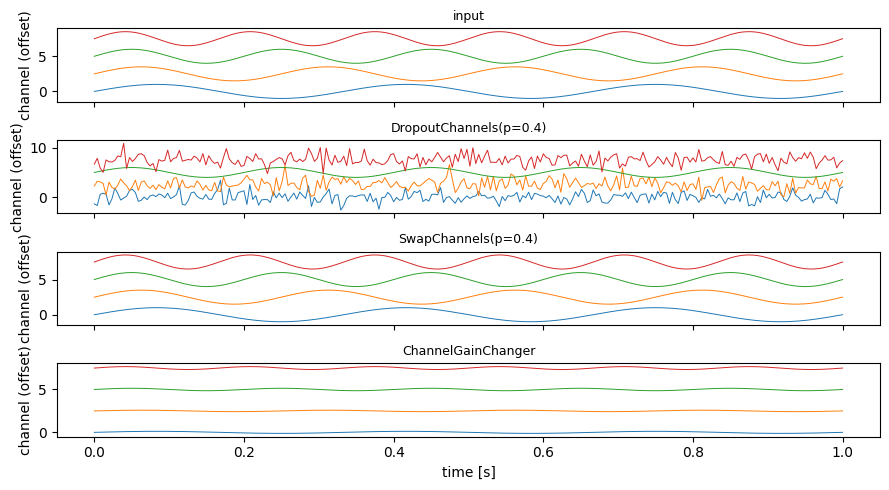

In [2]:
y_drop = scitex_nn.DropoutChannels(dropout=0.4).train()(x.clone()).detach()
y_swap = scitex_nn.SwapChannels(dropout=0.4).train()(x.clone()).detach()
y_gain = scitex_nn.ChannelGainChanger(n_chs=n_chs).train()(x.clone()).detach()

fig, axes = plt.subplots(4, 1, figsize=(9, 5), sharex=True)
for ax, (title, mat) in zip(
    axes,
    [
        ("input", x[0]),
        ("DropoutChannels(p=0.4)", y_drop[0]),
        ("SwapChannels(p=0.4)", y_swap[0]),
        ("ChannelGainChanger", y_gain[0]),
    ],
):
    for c in range(4):
        ax.plot(t.numpy(), mat[c].numpy() + c * 2.5, lw=0.7)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("channel (offset)")
axes[-1].set_xlabel("time [s]")
fig.tight_layout()
plt.show()